# HMM 레짐 분석 (Hidden Markov Model Regime Analysis)

> **목적**: 시장 데이터를 기반으로 숨겨진 시장 상태(레짐)를 자동 탐지합니다.  
> **데이터**: FF 팩터, 매크로 지표, 일별 수익률  
> **기간**: 2004 ~ 2026 (HMM 학습 cutoff = 2023-12-31, 2024~2025 는 hold-out)  

---

---

**관련 가이드**:
- [PROJECT_OVERVIEW.md](PROJECT_OVERVIEW.md) (전체 파이프라인)


In [1]:
import subprocess, sys
pkgs = ["hmmlearn", "scikit-learn", "matplotlib", "seaborn", "nbformat"]
for p in pkgs:
    result = subprocess.run(
        ["uv", "pip", "install", p, "--python", sys.executable, "-q"],
        capture_output=True
    )
    if result.returncode != 0:
        # fallback
        subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"])
print("✅ 설치 완료")

✅ 설치 완료


## 0. 라이브러리 임포트

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import platform
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
import pickle
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

# OS별 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 1. 경로 설정

In [3]:
BASE_DIR  = Path.cwd()
DATA_DIR  = BASE_DIR / 'data'
OUT_DIR   = BASE_DIR / 'outputs' / '05a_hmm_regime'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR: {DATA_DIR}")
print(f"OUT_DIR : {OUT_DIR}")

DATA_DIR: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/final_pt/data
OUT_DIR : /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/final_pt/outputs/05a_hmm_regime


## 2. 데이터 로드 & 전처리

| 파일 | 설명 |
|------|------|
| `ff_factors_daily.csv` | Fama-French 5팩터 + 모멘텀 (일별) |
| `macro_daily.csv` | VIX, WTI, 금리스프레드 등 매크로 (일별) |
| `daily_returns.pkl` | 개별 종목 일별 수익률 (5,595일 × 824종목) |


In [4]:
# ── FF 팩터 (일별) ──────────────────────────────────────────────────────────
ff = pd.read_csv(DATA_DIR / "ff_factors_daily.csv", parse_dates=["date"])
ff = ff.set_index("date").sort_index()

# ── 매크로 (일별) ────────────────────────────────────────────────────────────
macro = pd.read_csv(DATA_DIR / "macro_daily.csv", parse_dates=["date"])
macro = macro.set_index("date").sort_index()

# ── 일별 수익률 → 동일가중 시장 수익률 ──────────────────────────────────────
dr = pd.read_pickle(DATA_DIR / "daily_returns.pkl")
mkt_ret = dr.mean(axis=1).rename("mkt_ret_ew")

# ── 병합 ─────────────────────────────────────────────────────────────────────
df_raw = (ff
          .join(macro, how="left")
          .join(mkt_ret, how="left"))

print(f"병합 데이터 shape: {df_raw.shape}")
print(f"기간: {df_raw.index[0].date()} ~ {df_raw.index[-1].date()}")
df_raw.head(3)


병합 데이터 shape: (5596, 20)
기간: 2004-01-02 ~ 2026-03-31


,mkt_rf,smb,hml,rmw,cma,rf,mom_factor,wti_crude,dxy,gold,copper,silver,skew_idx,vix,t10y2y,icsa,sahm,cpi,unrate,mkt_ret_ew
date,,,,,,,,,,,,,,,,,,,,
2004-01-02,-0.0017,0.0080,0.0042,-0.0058,0.0060,0.0,0.0002,NaN,86.919998,NaN,NaN,NaN,123.230003,18.219999,3.471,NaN,NaN,NaN,NaN,NaN
2004-01-05,0.0120,0.0026,0.0001,-0.0075,0.0082,0.0,0.0055,33.779999,86.070000,424.399994,1.083,6.233,121.150002,17.490000,3.485,NaN,NaN,NaN,NaN,0.010830
2004-01-06,0.0020,0.0005,0.0027,-0.0047,0.0056,0.0,0.0071,33.700001,85.629997,422.799988,1.067,6.316,125.190002,16.730000,3.376,NaN,NaN,NaN,NaN,0.002009


## 3. 피처 엔지니어링

HMM 입력으로 사용할 16개 피처를 생성합니다.

| 그룹 | 피처 |
|------|------|
| 수익률·모멘텀 | mkt_rf, mkt_ret_ew, ret_5d, ret_21d |
| 변동성 | vol_21d_daily, vol_63d_daily |
| FF 팩터 | smb, hml, mom |
| 공포·심리 | vix, vix_chg |
| 금리 | t10y2y, t10y2y_chg |
| 원자재 | wti_ret, gold_ret, dxy_ret |


In [5]:
feat = pd.DataFrame(index=df_raw.index)

# 수익률 & 모멘텀
feat["mkt_rf"]     = df_raw["mkt_rf"]
feat["mkt_ret_ew"] = df_raw["mkt_ret_ew"]
feat["vol_21d_daily"]    = df_raw["mkt_rf"].rolling(21).std()
feat["vol_63d_daily"]    = df_raw["mkt_rf"].rolling(63).std()
feat["ret_5d"]     = df_raw["mkt_rf"].rolling(5).mean()
feat["ret_21d"]    = df_raw["mkt_rf"].rolling(21).mean()

# FF 팩터
feat["smb"] = df_raw["smb"]
feat["hml"] = df_raw["hml"]
feat["mom"] = df_raw.get("mom_factor", pd.Series(np.nan, index=df_raw.index))

# 공포 지수
feat["vix"]      = df_raw["vix"]
feat["vix_chg"]  = df_raw["vix"].diff()

# 금리
feat["t10y2y"]     = df_raw["t10y2y"]
feat["t10y2y_chg"] = df_raw["t10y2y"].diff()

# 원자재
feat["wti_ret"]  = df_raw["wti_crude"].pct_change()
feat["gold_ret"] = df_raw["gold"].pct_change()
feat["dxy_ret"]  = df_raw["dxy"].pct_change()

feat_df = feat.dropna(subset=["mkt_rf", "vol_21d_daily"]).ffill().dropna()

# ── NaN 처리 결과 진단 ────────────────────────────────────────────────────────
total_rows   = len(feat)
after_dropna = len(feat.dropna(subset=["mkt_rf", "vol_21d_daily"]))
after_ffill  = len(feat_df)

print(f"원본 거래일    : {total_rows:>6,}일")
print(f"vol_21d_daily 초기화 : {after_dropna:>6,}일  (제거 {total_rows - after_dropna}일 — vol_21d_daily 21일 워밍업)")
print(f"최종 feat_df   : {after_ffill:>6,}일  (추가 제거 {after_dropna - after_ffill}일)")
print(f"기간: {feat_df.index[0].date()} ~ {feat_df.index[-1].date()}")
print(f"피처 수   : {feat_df.shape[1]}\n")

# ── 컬럼별 NaN 현황 (ffill 전) ───────────────────────────────────────────────
nan_before = feat.dropna(subset=["mkt_rf", "vol_21d_daily"]).isna().sum()
nan_cols   = nan_before[nan_before > 0].sort_values(ascending=False)
if len(nan_cols) > 0:
    print("ffill 전 NaN이 있는 컬럼:")
    for col, cnt in nan_cols.items():
        print(f"  {col:<14}: {cnt:>5}일 ({cnt/after_dropna*100:.1f}%)")
else:
    print("ffill 전 NaN 없음 ✅")

# ── 날짜 연속성 확인 ──────────────────────────────────────────────────────────
date_diff = feat_df.index.to_series().diff().dt.days.dropna()
max_gap   = date_diff.max()
gap_days  = date_diff[date_diff > 5]  # 5거래일 이상 공백

print(f"\n날짜 gap 분석:")
print(f"  평균 간격  : {date_diff.mean():.2f}일 (정상 = ~1.4, 주말 포함)")
print(f"  최대 gap   : {int(max_gap)}일")
if len(gap_days) > 0:
    print(f"  5일 초과 gap: {len(gap_days)}건")
    for dt, gap in gap_days.items():
        print(f"    {dt.date()}  (전일 대비 +{int(gap)}일)")
else:
    print("  5일 초과 gap: 없음 ✅")
    
feat_df.describe().round(5)


원본 거래일    :  5,596일
vol_21d_daily 초기화 :  5,576일  (제거 20일 — vol_21d_daily 21일 워밍업)
최종 feat_df   :  5,534일  (추가 제거 42일)
기간: 2004-04-01 ~ 2026-03-31
피처 수   : 16

ffill 전 NaN이 있는 컬럼:
  vol_63d_daily :    42일 (0.8%)
  t10y2y_chg    :    11일 (0.2%)
  t10y2y        :     6일 (0.1%)
  mkt_ret_ew    :     1일 (0.0%)
  vix           :     1일 (0.0%)
  vix_chg       :     1일 (0.0%)

날짜 gap 분석:
  평균 간격  : 1.45일 (정상 = ~1.4, 주말 포함)
  최대 gap   : 5일
  5일 초과 gap: 없음 ✅


,mkt_rf,mkt_ret_ew,vol_21d_daily,vol_63d_daily,ret_5d,ret_21d,smb,hml,mom,vix,vix_chg,t10y2y,t10y2y_chg,wti_ret,gold_ret,dxy_ret
count,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000,5534.00000
mean,0.00040,0.00037,0.01006,0.01039,0.00040,0.00041,-0.00001,0.00000,0.00010,19.02128,0.00243,1.31740,-0.00044,-0.00014,0.00049,0.00004
std,0.01205,0.01322,0.00676,0.00615,0.00490,0.00224,0.00633,0.00786,0.01041,8.50455,1.88498,1.24359,0.06384,0.05166,0.01143,0.00478
min,-0.12010,-0.13992,0.00248,0.00346,-0.03964,-0.01784,-0.04580,-0.05030,-0.14370,9.14000,-18.71000,-1.70400,-0.51800,-3.05966,-0.11366,-0.02680
25%,-0.00430,-0.00477,0.00610,0.00701,-0.00176,-0.00061,-0.00370,-0.00340,-0.00420,13.49000,-0.71000,0.35000,-0.03300,-0.01232,-0.00486,-0.00265
50%,0.00070,0.00083,0.00824,0.00837,0.00077,0.00069,-0.00010,-0.00020,0.00060,16.60000,-0.09500,1.42550,-0.00000,0.00109,0.00050,0.00000
75%,0.00590,0.00644,0.01172,0.01170,0.00298,0.00170,0.00350,0.00320,0.00510,21.84000,0.57000,2.20500,0.03200,0.01323,0.00644,0.00274
max,0.11360,0.10808,0.06088,0.04452,0.03654,0.01129,0.05710,0.06730,0.07140,82.69000,24.86000,3.87100,0.75900,0.37662,0.09028,0.02556


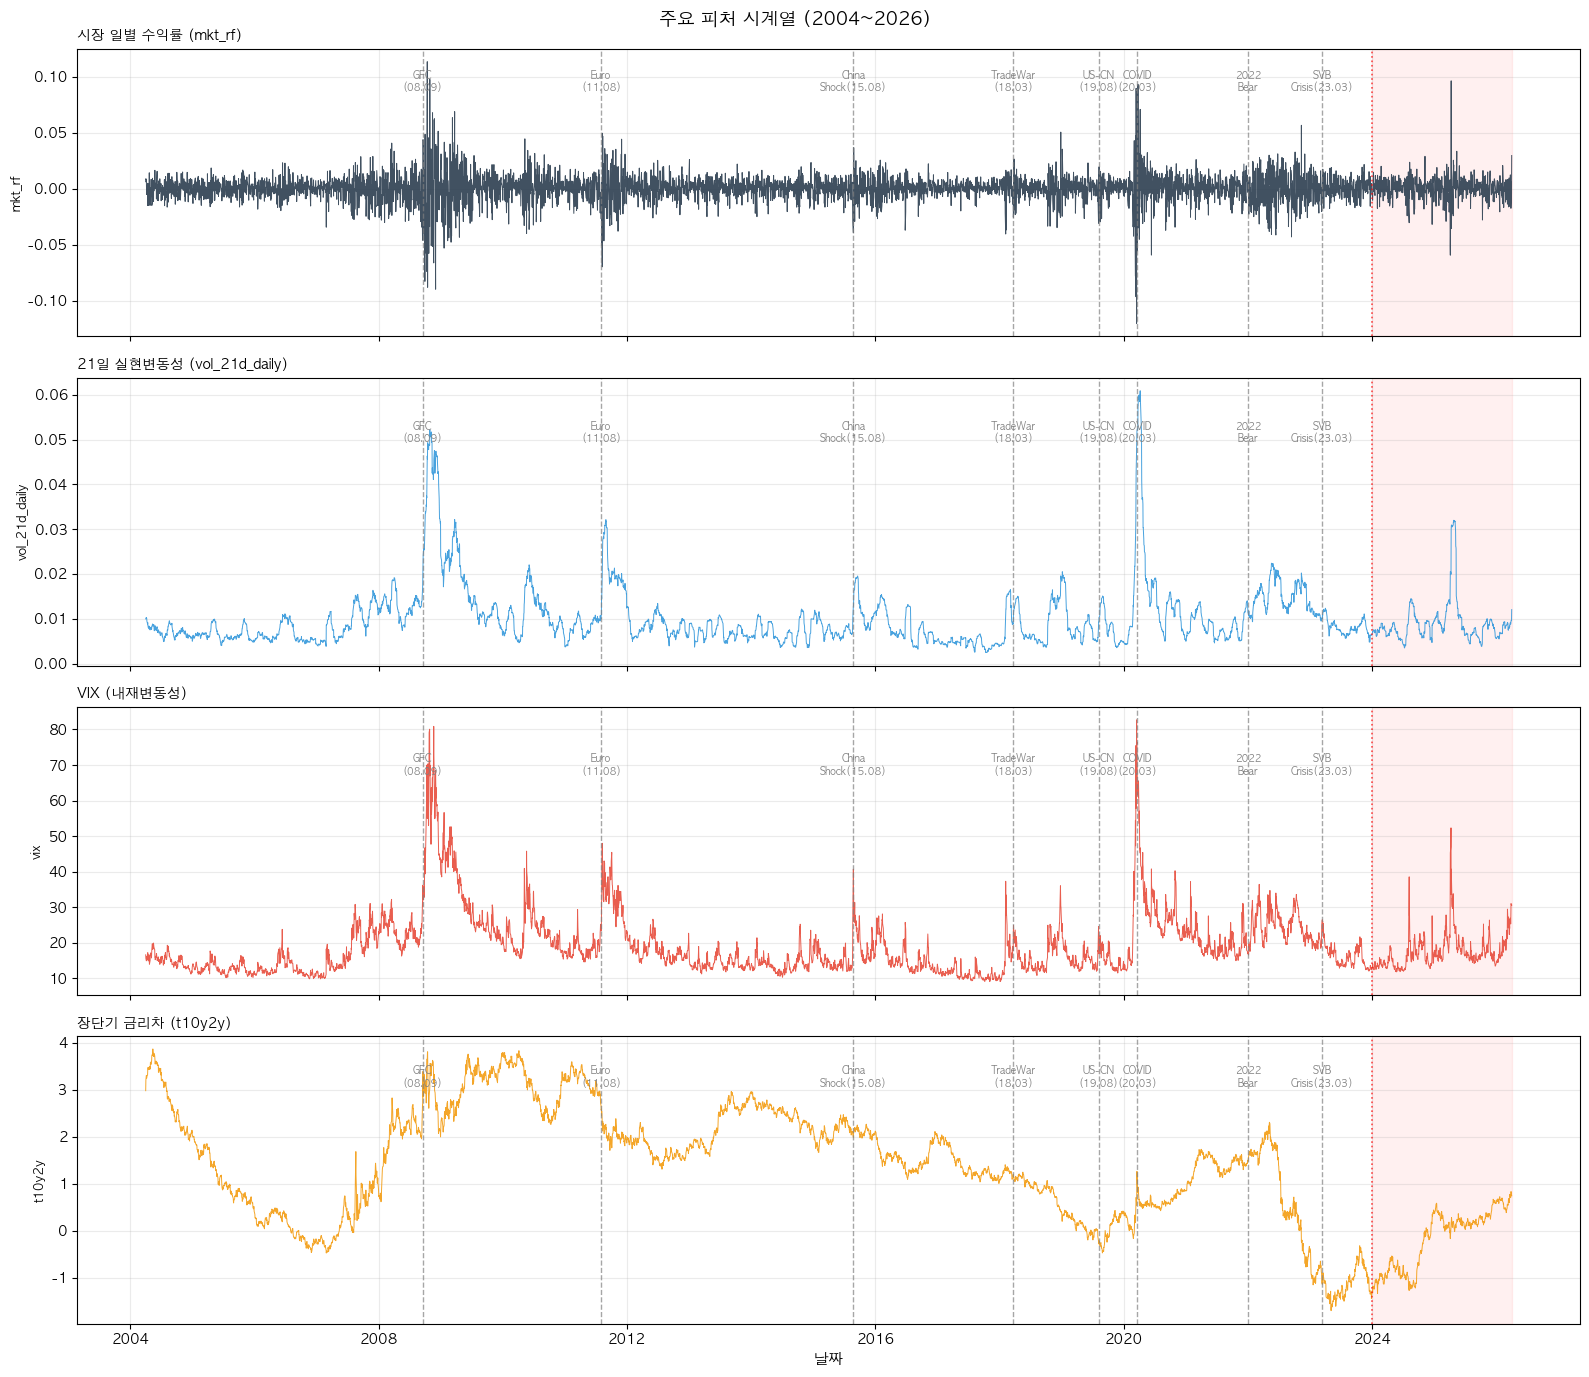

In [6]:
# ── 주요 피처 시계열 시각화 ────────────────────────────────────────────────────
EVENTS = {
    "GFC\n(08.09)": "2008-09-15",
    "Euro\n(11.08)": "2011-08-01",
    "China\nShock(15.08)": "2015-08-24",
    "TradeWar\n(18.03)": "2018-03-22",
    "US-CN\n(19.08)": "2019-08-05",
    "COVID\n(20.03)": "2020-03-20",
    "2022\nBear":   "2022-01-01",
    "SVB\nCrisis(23.03)": "2023-03-10"
}

plot_series = [
    ("mkt_rf",   "시장 일별 수익률 (mkt_rf)",      "#2c3e50"),
    ("vol_21d_daily",  "21일 실현변동성 (vol_21d_daily)",      "#3498db"),
    ("vix",      "VIX (내재변동성)",               "#e74c3c"),
    ("t10y2y",   "장단기 금리차 (t10y2y)",         "#f39c12"),
]

fig, axes = plt.subplots(len(plot_series), 1, figsize=(16, 14), sharex=True)

for ax, (col, title, color) in zip(axes, plot_series):
    if col not in feat_df.columns:
        ax.set_visible(False)
        continue
    ax.plot(feat_df.index, feat_df[col], color=color, lw=0.7, alpha=0.9)
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left")
    ax.grid(alpha=0.25)
    for label, date_str in EVENTS.items():
        try:
            dt = pd.Timestamp(date_str)
            if feat_df.index[0] <= dt <= feat_df.index[-1]:
                ax.axvline(dt, color="gray", lw=1.0, linestyle="--", alpha=0.7)
                ax.text(dt, ax.get_ylim()[1] * 0.85, label,
                        fontsize=7, color="gray", ha="center", va="top")
        except Exception:
            pass
    # hold-out cutoff 표시
    K_CUT_VIS = pd.Timestamp('2023-12-31')
    if feat_df.index[0] <= K_CUT_VIS <= feat_df.index[-1]:
        ax.axvspan(K_CUT_VIS, feat_df.index[-1], color='red', alpha=0.06)
        ax.axvline(K_CUT_VIS, color='red', lw=1.2, alpha=0.7, linestyle=':')

axes[-1].set_xlabel("날짜", fontsize=11)
plt.suptitle("주요 피처 시계열 (2004~2026)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "EDA_feature_timeseries.png", bbox_inches="tight")
plt.show()

In [7]:
# ── K_CUT: HMM 학습 데이터 cutoff ────────────────────────────────
# HMM EM 은 데이터 끝 변화에 매우 민감 (5500일 중 마지막 22일 추가만으로 수렴점 점프 관찰).
# 추가로 ADF/VIF/상관 등 통계 기반 피처 선택 결정도 hold-out 정보 누설 차단을 위해
# 이 시점부터 K_CUT 후 데이터만 사용.
#
# K_CUT = 2023-12-31 (hold-out 2024~2025 분리, 05b_Analyze 와 동일 cutoff)
# - bl_config.EVAL_PERIODS 의 TEST=2010-2023 와 정합
# - hold-out 정보가 ADF·VIF → 피처 선택 → HMM 학습 → REGIMES → 05b/06 으로 leak 되는 것 차단
# - 셀 9 피처 엔지니어링 (rolling, diff) 은 causal 연산이라 leak 무관
# - 셀 10 시계열 시각화는 전체 기간 보존 (모델 영향 0, hold-out 구간 vline 으로 표시)
K_CUT = pd.Timestamp('2023-12-31')
before = len(feat_df)
feat    = feat[feat.index <= K_CUT]     # 셀 15 의 feat_df 재정의도 K_CUT 후만 사용하도록
feat_df = feat_df[feat_df.index <= K_CUT]
print(f'K_CUT = {K_CUT.date()}')
print(f'feat_df: {before:,}일 → {len(feat_df):,}일  (제거 {before - len(feat_df)}일)')
print(f'학습 기간: {feat_df.index[0].date()} ~ {feat_df.index[-1].date()}')


K_CUT = 2023-12-31
feat_df: 5,534일 → 4,971일  (제거 563일)
학습 기간: 2004-04-01 ~ 2023-12-29


### 피처 적절성 검증

| 검증 방법 | 판단 기준 |
|-----------|-----------|
| **ADF 검정** | p > 0.05이면 차분 |
| **상관 행렬 (Heatmap)** | 0.7 이하 |
| **VIF (분산팽창요인)** | VIF > 10이면 다중공선성 심각, 5~10이면 주의 |

In [8]:
def check_stationarity(df):
    """
    각 컬럼에 대해 ADF 검정을 수행하여 정상성 여부를 확인합니다.
    """
    results = []
    cols = df.columns
    
    for col in cols:
        series = df[col].dropna()
        
        if len(series) < 20 or series.nunique() <= 1:
            results.append({
                "feature": col, 
                "adf_stat": None, 
                "p_value": None, 
                "is_stationary": "Data Issue"
            })
            continue
            
        res = adfuller(series)
        p_val = res[1]
        
        results.append({
            "feature": col,
            "adf_stat": res[0],
            "p_value": p_val,
            "is_stationary": "Yes" if p_val < 0.05 else "No (Non-stationary)"
        })
        
    return pd.DataFrame(results).sort_values("p_value")

stationarity_df = check_stationarity(feat_df)

print("## 피처별 정상성 검정 결과 (ADF Test)")
print(stationarity_df)

non_stationary_features = stationarity_df[stationarity_df['is_stationary'] == "No (Non-stationary)"]['feature'].tolist()
print(f"\n→ 정상성 처리가 필요한 지표: {non_stationary_features}")
print(f"   (셀 16 에서 t10y2y → t10y2y_chg 1차 차분으로 대체, 선별 6피처는 모두 정상)")

## 피처별 정상성 검정 결과 (ADF Test)
          feature   adf_stat       p_value        is_stationary
6             smb -51.948988  0.000000e+00                  Yes
10        vix_chg -23.983544  0.000000e+00                  Yes
14       gold_ret -22.446014  0.000000e+00                  Yes
15        dxy_ret -21.334232  0.000000e+00                  Yes
0          mkt_rf -17.347600  5.294504e-30                  Yes
1      mkt_ret_ew -15.376554  3.452177e-28                  Yes
13        wti_ret -13.018588  2.481016e-24                  Yes
4          ret_5d -12.396597  4.660280e-23                  Yes
12     t10y2y_chg -11.974662  3.826637e-22                  Yes
8             mom -11.929642  4.815020e-22                  Yes
7             hml -10.731092  2.978549e-19                  Yes
5         ret_21d -10.555693  7.963409e-19                  Yes
2   vol_21d_daily  -6.368177  2.381108e-08                  Yes
3   vol_63d_daily  -5.764755  5.565981e-07                  Yes
9           

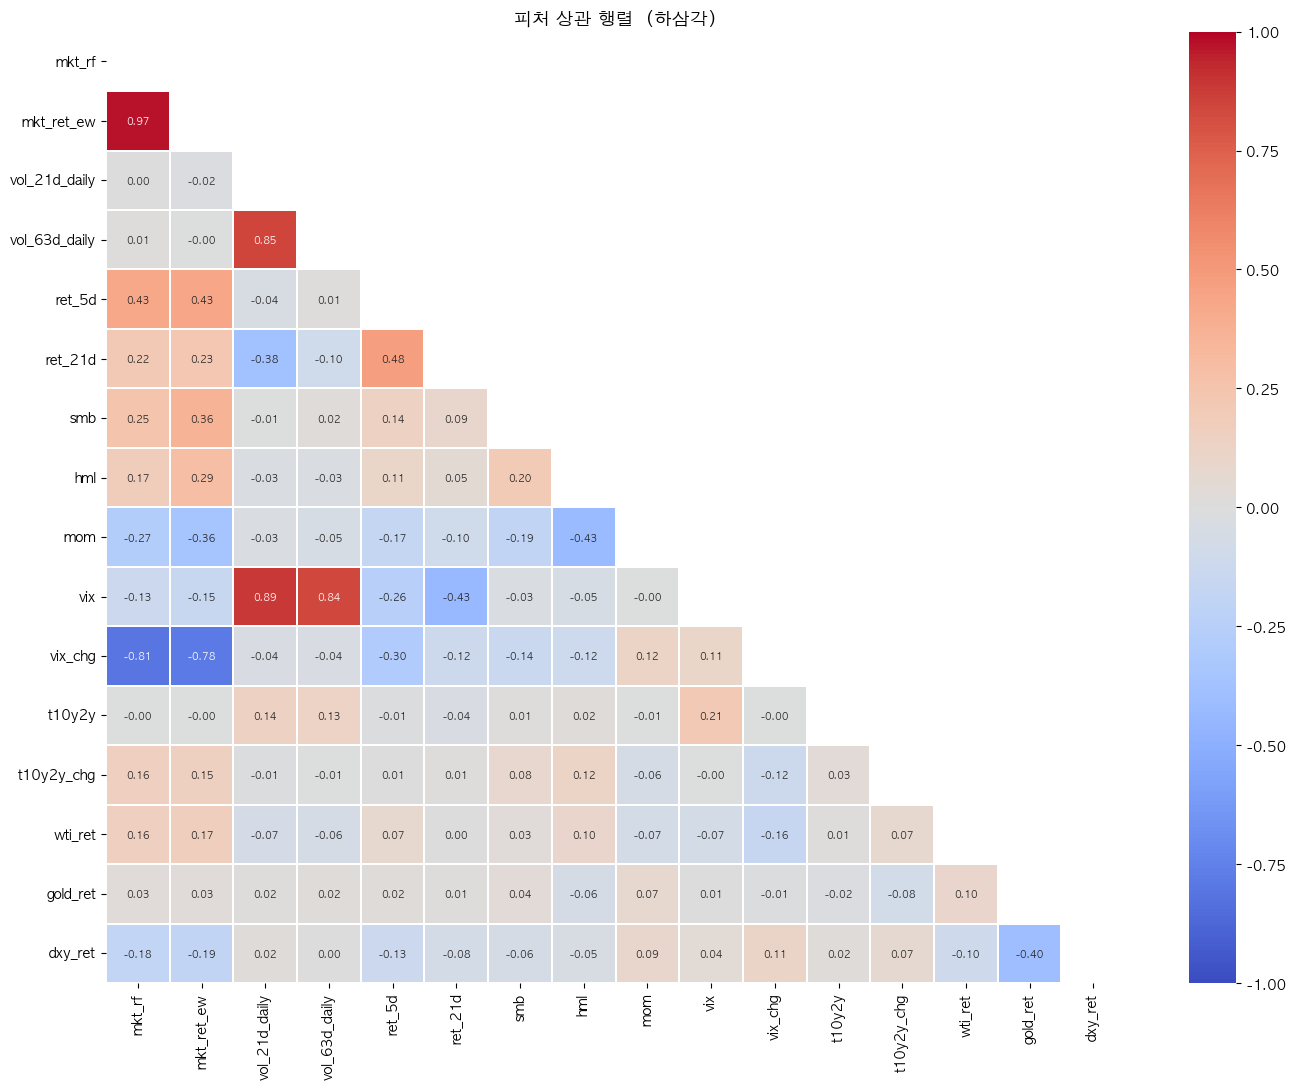

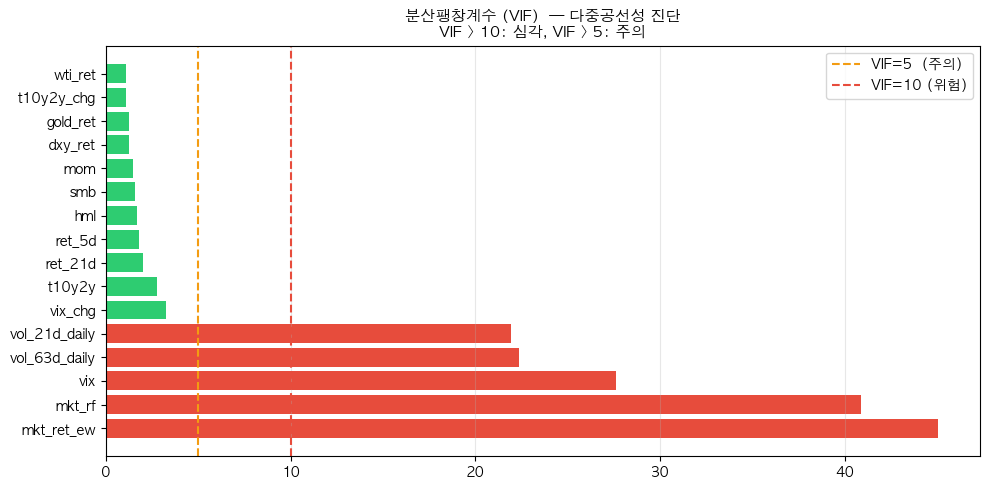

      feature       VIF
   mkt_ret_ew 45.076220
       mkt_rf 40.892164
          vix 27.640262
vol_63d_daily 22.367496
vol_21d_daily 21.921668
      vix_chg  3.249475
       t10y2y  2.764150
      ret_21d  1.978822
       ret_5d  1.778115
          hml  1.671485
          smb  1.597165
          mom  1.454200
      dxy_ret  1.263079
     gold_ret  1.227876
   t10y2y_chg  1.070230
      wti_ret  1.063815


In [9]:
# ── 상관 행렬 ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
corr = feat_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.3, ax=ax, annot_kws={"size": 7},
            vmin=-1, vmax=1)
ax.set_title("피처 상관 행렬  (하삼각)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "V1_correlation_matrix.png", bbox_inches="tight")
plt.show()

# ── VIF ──────────────────────────────────────────────────────────────────────
vif_vals = [variance_inflation_factor(feat_df.values, i)
            for i in range(feat_df.shape[1])]
vif_df = (pd.DataFrame({"feature": feat_df.columns, "VIF": vif_vals})
            .sort_values("VIF", ascending=False)
            .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 5))
vcolors = ["#e74c3c" if v > 10 else "#f39c12" if v > 5 else "#2ecc71"
           for v in vif_df["VIF"]]
ax.barh(vif_df["feature"], vif_df["VIF"], color=vcolors)
ax.axvline(5,  color="#f39c12", linestyle="--", lw=1.5, label="VIF=5  (주의)")
ax.axvline(10, color="#e74c3c", linestyle="--", lw=1.5, label="VIF=10 (위험)")
ax.set_title("분산팽창계수 (VIF)  — 다중공선성 진단\nVIF > 10: 심각, VIF > 5: 주의",
             fontweight="bold", fontsize=11)
ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "V2_vif.png", bbox_inches="tight")
plt.show()

print(vif_df.to_string(index=False))

### 최종 피처 선택

> 16개 후보 중 **이론적 근거 + 통계 검증** 두 단계를 거쳐 6개 선별

| 피처 | 선택 근거 |
|------|----------|
| `mkt_rf` | 레짐의 직접 결과물 — Bull/Bear 구분의 핵심 수익 신호 |
| `vol_21d_daily` | 레짐 라벨링 기준 자체 (변동성 순 정렬로 Bull→Crisis 부여) |
| `vol_ratio` | 단기/장기 변동성 비율 → 레짐 **전환 선행** 신호 (급등 감지) |
| `vix_basis` | 기대−실현 변동성 갭 → 음수 = 공포 실현, Bear/Crisis 식별 |
| `t10y2y_chg` | 경기 국면 변화 선행지표 — 금리 역전 후 침체 패턴 포착 |
| `mom` | 추세 지속성 — Bull은 모멘텀 양수, Bear는 모멘텀 음수 |

- ADF: `t10y2y` → `t10y2y_chg`로 대체, 나머지 정상
- 상관/VIF 기반 탈락:
  - `mkt_ret_ew`·`ret_5d`·`ret_21d` → `mkt_rf`와 상관 0.7↑
  - `vol_63d_daily` → `vol_21d_daily`와 중복
  - `vix`·`vix_chg` → `vix_basis`로 통합
  - `smb`·`hml` → 레짐 간 평균 차이 미미
- 선별 후 모든 피처 VIF < 6 (vol_ratio 5.8, 임계 10 미만) → 다중공선성 양호
- **ADF/VIF/상관 모두 K_CUT=2023-12-31 후 4,971일 데이터로 계산** (hold-out 누설 차단)

→ 이론적으로 의미 있는 피처를 먼저 선정하고, 통계 검증으로 다중공선성 없음을 사후 확인

선별 피처: ['mkt_rf', 'vol_21d_daily', 'vol_ratio', 'vix_basis', 't10y2y_chg', 'mom']
유효 거래일: 4,971일


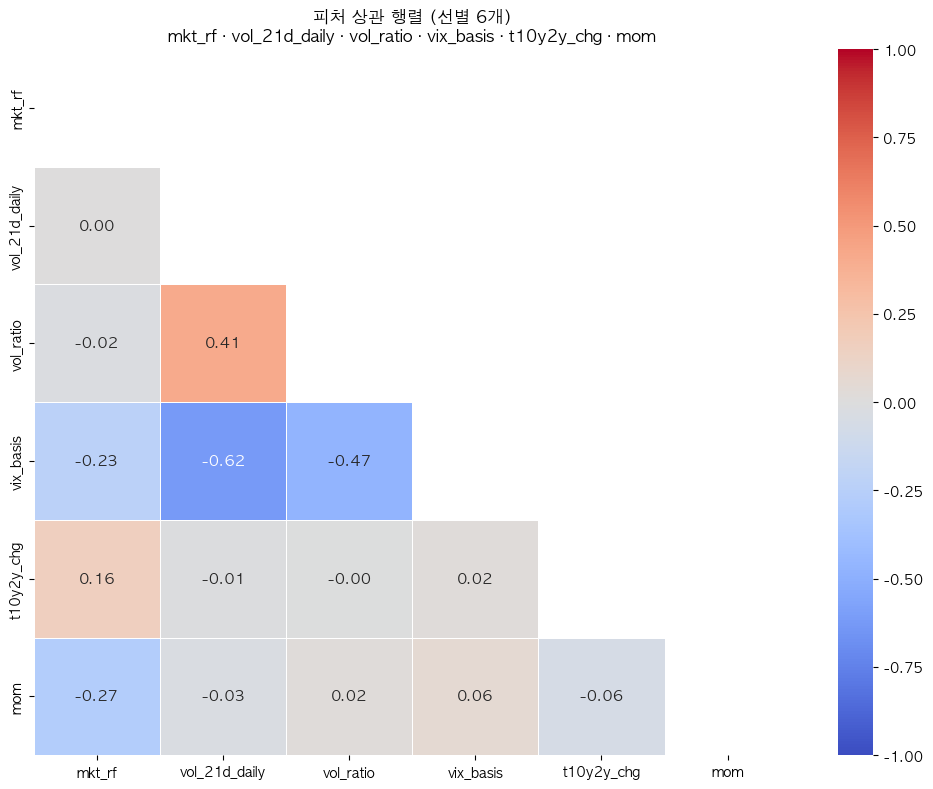

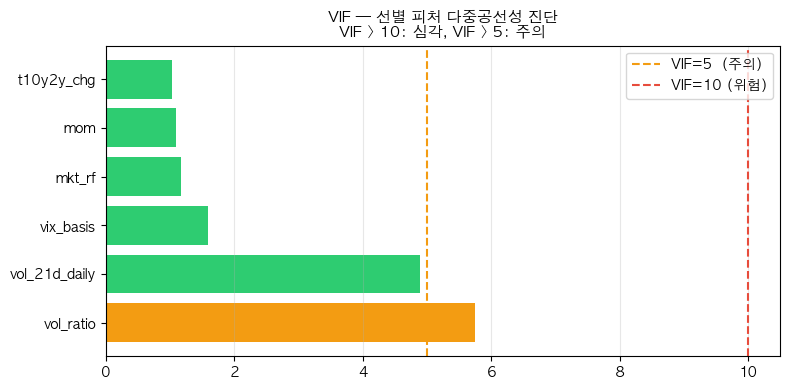

      feature      VIF
    vol_ratio 5.755256
vol_21d_daily 4.887827
    vix_basis 1.596980
       mkt_rf 1.171588
          mom 1.083617
   t10y2y_chg 1.028879


In [10]:
# ── vol_ratio, vix_basis 추가 & 선별 피처로 feat_df 재정의 ─────────────────
feat["vol_ratio"] = feat["vol_21d_daily"] / feat["vol_63d_daily"]
feat["vix_basis"] = feat["vix"] - feat["vol_21d_daily"] * np.sqrt(252) * 100

SELECTED_FEATURES = ["mkt_rf", "vol_21d_daily", "vol_ratio", "vix_basis", "t10y2y_chg", "mom"]
feat_df = (feat[SELECTED_FEATURES]
           .dropna(subset=["mkt_rf", "vol_21d_daily"])
           .ffill()
           .dropna())

print(f"선별 피처: {list(feat_df.columns)}")
print(f"유효 거래일: {feat_df.shape[0]:,}일")

# ── 상관 행렬 ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = feat_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 11},
            vmin=-1, vmax=1)
ax.set_title("피처 상관 행렬 (선별 6개)\nmkt_rf · vol_21d_daily · vol_ratio · vix_basis · t10y2y_chg · mom",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "V3_corr_selected.png", bbox_inches="tight")
plt.show()

# ── VIF ──────────────────────────────────────────────────────────────────────
vif_vals = [variance_inflation_factor(feat_df.values, i)
            for i in range(feat_df.shape[1])]
vif_df2 = (pd.DataFrame({"feature": feat_df.columns, "VIF": vif_vals})
             .sort_values("VIF", ascending=False)
             .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 4))
vcolors = ["#e74c3c" if v > 10 else "#f39c12" if v > 5 else "#2ecc71"
           for v in vif_df2["VIF"]]
ax.barh(vif_df2["feature"], vif_df2["VIF"], color=vcolors)
ax.axvline(5,  color="#f39c12", linestyle="--", lw=1.5, label="VIF=5  (주의)")
ax.axvline(10, color="#e74c3c", linestyle="--", lw=1.5, label="VIF=10 (위험)")
ax.set_title("VIF — 선별 피처 다중공선성 진단\nVIF > 10: 심각, VIF > 5: 주의",
             fontweight="bold", fontsize=11)
ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "V4_vif_selected.png", bbox_inches="tight")
plt.show()

print(vif_df2.to_string(index=False))

---
**최종 피처 선택 요약**

- 선별된 6개: `mkt_rf`, `vol_21d_daily`, `vol_ratio`, `vix_basis`, `t10y2y_chg`, `mom`
- `vol_ratio`(단기/장기 변동성 비율): 1보다 크면 변동성 급증기, 작으면 안정기 → 레짐 전환 신호
- `vix_basis`(기대 변동성 − 실현 변동성): 음수이면 공포가 실현된 Bear 국면 식별
- 선별 후 모든 피처 VIF < 6 (vol_ratio 5.8, 임계 10 미만) → 다중공선성 양호, HMM 입력으로 적합
- **ADF·VIF·상관 통계 모두 K_CUT=2023-12-31 후 데이터(4,971일) 로 계산** → hold-out 정보가 피처 선택 결정에 leak 되지 않음


In [11]:
import matplotlib.dates as mdates

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(feat_df.values)

print(f"X_scaled shape: {X_scaled.shape}")
print(f"피처 순서: {list(feat_df.columns)}")

X_scaled shape: (4971, 6)
피처 순서: ['mkt_rf', 'vol_21d_daily', 'vol_ratio', 'vix_basis', 't10y2y_chg', 'mom']


---
**HMM 학습 준비 완료**

- 입력 행렬 `X_scaled`: (4,971일 × 6피처), StandardScaler 정규화 (K_CUT 후 데이터로만 fit)
- K_CUT=2023-12-31 적용 (hold-out 2024~2025 분리, 05b_Analyze 와 동일 cutoff)
- **피처 선택 (ADF/VIF/상관)·StandardScaler·HMM 학습 모두 K_CUT 후 데이터 기반** → hold-out 완전 격리
- 셀 9 피처 엔지니어링 (rolling/diff)·셀 10 시각화는 causal/inspection-only 라 전체 기간 유지
- 이후 `n = 3, 4, 5` 세 가지 레짐 수로 Full-Fit HMM을 학습하고  
  AIC/BIC, 레짐 안정성, 경제적 해석 가능성을 기준으로 최적 n을 비교한다



## 4. Full-Fit HMM 분석
전체 데이터를 한 번에 학습하여 시장의 역사적인 레짐 구조와 전이 확률(Transition Matrix)을 분석한다.

---
**분석 로드맵**

```
Full-Fit HMM 학습 (섹션 4)
    ↓ 레짐 존재 확인
레짐 통계 비교 (섹션 5) — 수익/변동성/VIX 분포
    ↓ 레짐이 통계적으로 유의미한가?
피처 분포 비교 (섹션 6) — KDE로 분리도 시각화
    ↓ 레짐 경계 신뢰도 확인
전이 행렬 (섹션 7) — 레짐 지속성 확인
    ↓ 포트폴리오 적용 가능 여부 판단
구조적 전환점 (섹션 8) → Posterior 신뢰도 (섹션 9)
```

In [12]:
def run_full_hmm(X, feat_df_in, n_components=4, seed=42):
    """
    전체 구간에 대해 HMM을 피팅하고 변동성 기준으로 레짐을 해석
    """
    model = GaussianHMM(
        n_components=n_components, covariance_type="full",
        n_iter=1000, random_state=seed
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model.fit(X)
    states = model.predict(X)

    vol_data = feat_df_in["vol_21d_daily"].values
    state_vols = {
        s: vol_data[states == s].mean() if (states == s).any() else float("inf")
        for s in range(n_components)
    }
    sorted_states = sorted(state_vols.keys(), key=lambda s: state_vols[s])
    raw_to_rank = {raw: rank for rank, raw in enumerate(sorted_states)}

    label_map = {
        3: ["Bull", "Neutral", "Bear"],
        4: ["Bull", "Mild_Bull", "Neutral", "Bear"],
        5: ["Bull", "Mild_Bull", "Neutral", "Bear", "Crisis"],
    }
    labels = label_map.get(n_components, [f"R{i}" for i in range(n_components)])

    trans_mat = model.transmat_[sorted_states, :][:, sorted_states]

    return {
        "model": model,
        "states": [raw_to_rank[s] for s in states],
        "trans_matrix": pd.DataFrame(trans_mat, index=labels, columns=labels),
        "labels": labels,
        "state_vols": state_vols,
    }

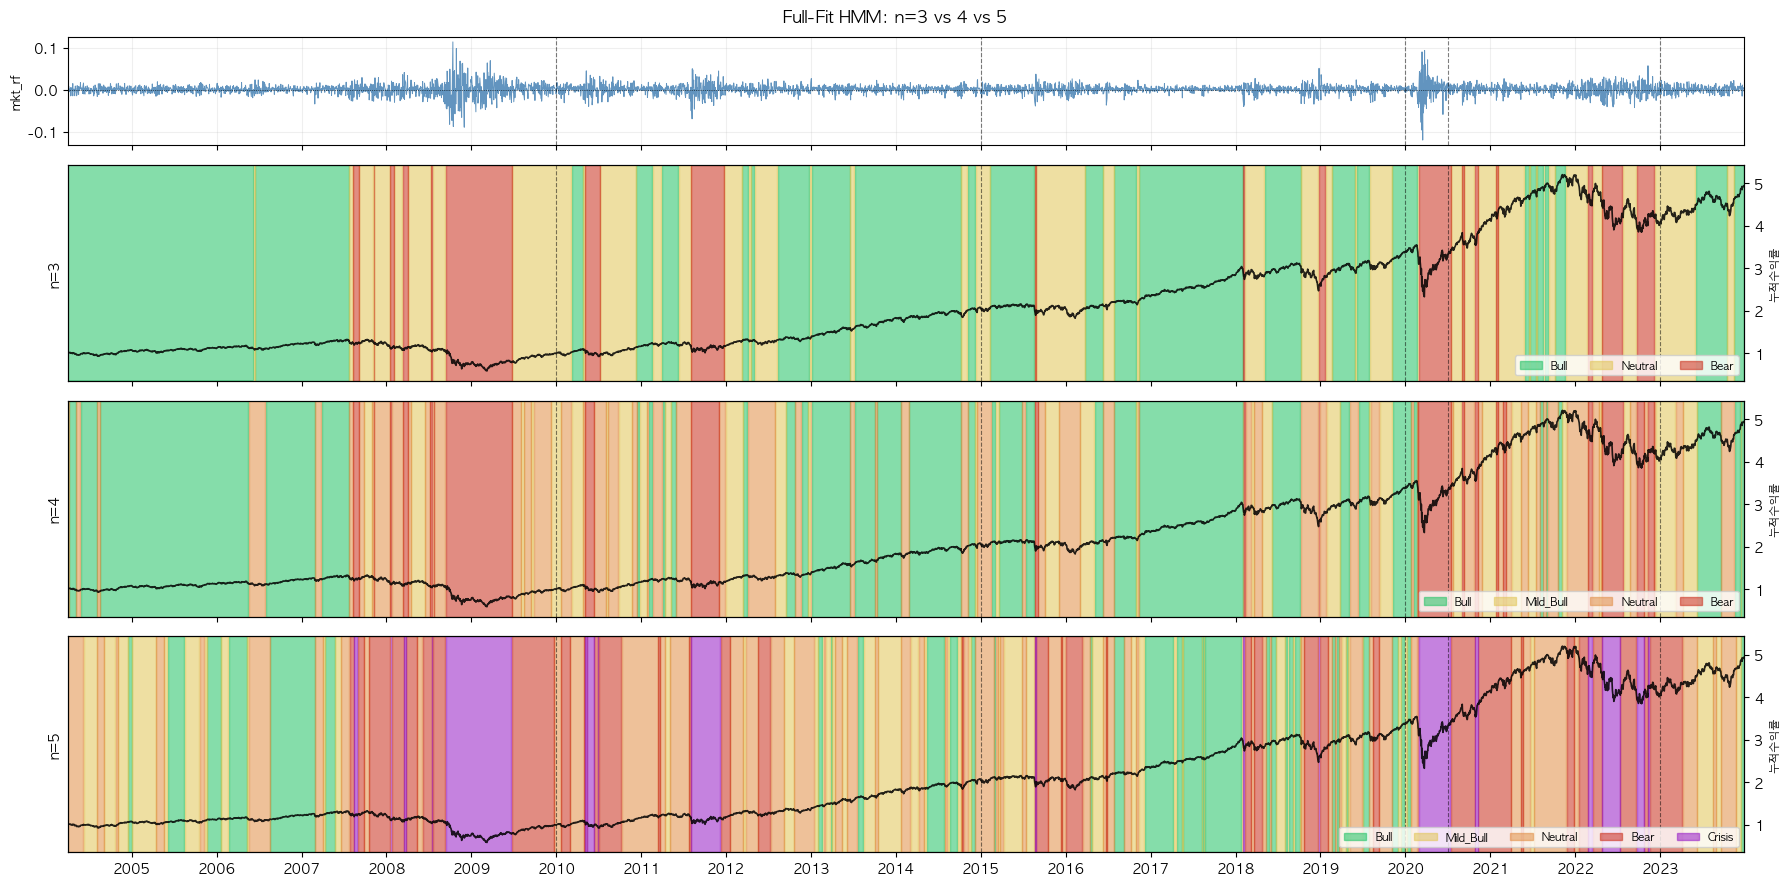

In [13]:
# ── Full-fit n=3,4,5 실행 ─────────────────────────────────────────────────
results = {}
for n_comp in [3, 4, 5]:
    results[n_comp] = run_full_hmm(X_scaled, feat_df, n_components=n_comp)

# ── 1. 타임라인 ──────────────────────────────────────────────────────────────
dates        = feat_df.index
N_COLORS = {
    3: ["#21c164", "#e1c556", "#ca2e1c"],
    4: ["#21c164", "#e1c556", "#e18e45", "#ca2e1c"],
    5: ["#21c164", "#e1c556", "#e18e45", "#ca2e1c", "#961cc6"],
}
period_lines = ["2010-01-01", "2015-01-01", "2020-01-01", "2020-07-01", "2023-01-01"]
cum_ret      = (1 + feat_df["mkt_rf"]).cumprod()

fig, axes = plt.subplots(4, 1, figsize=(18, 9), sharex=True,
                         gridspec_kw={"height_ratios": [1, 2, 2, 2]})

# ── mkt_rf (맨 위) ──
axes[0].plot(dates, feat_df["mkt_rf"], color="steelblue", lw=0.7, alpha=0.85)
axes[0].axhline(0, color="black", lw=0.5, linestyle=":")
axes[0].set_ylabel("mkt_rf", fontsize=9)
axes[0].grid(alpha=0.2)
for d in period_lines:
    axes[0].axvline(pd.Timestamp(d), color="black", linestyle="--", lw=0.8, alpha=0.5)

# ── 레짐 + 누적수익률 ──
for ax, (n_comp, res) in zip(axes[1:], results.items()):
    s_arr = np.array(res["states"])
    lbls  = res["labels"]
    for regime, color in enumerate(N_COLORS[n_comp]):
        ax.fill_between(dates, 0, 1, where=(s_arr == regime),
                        color=color, alpha=0.55, label=lbls[regime])
    for d in period_lines:
        ax.axvline(pd.Timestamp(d), color="black", linestyle="--", lw=0.8, alpha=0.5)
    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.set_ylabel(f"n={n_comp}", fontsize=10)
    ax.legend(loc="lower right", ncol=n_comp, fontsize=8)

    ax2 = ax.twinx()
    ax2.plot(dates, cum_ret, color="black", lw=1.2, alpha=0.85)
    ax2.set_ylabel("누적수익률", fontsize=8)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlim(dates[0], dates[-1])
fig.suptitle("Full-Fit HMM: n=3 vs 4 vs 5", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "full_timeline_n345.png", dpi=150, bbox_inches="tight")
plt.show()

### 피처 중요도

n=3  레짐 분리력 순위:
  1. vol_21d_daily    std=1.2166  🔴 HIGH
  2. vix_basis        std=0.4683  🔴 HIGH
  3. vol_ratio        std=0.2800  🟡 MID 
  4. mom              std=0.0698  🔵 LOW 
  5. mkt_rf           std=0.0332  🔵 LOW 
  6. t10y2y_chg       std=0.0138  🔵 LOW 

n=4  레짐 분리력 순위:
  1. vol_21d_daily    std=1.0941  🔴 HIGH
  2. vol_ratio        std=0.7668  🔴 HIGH
  3. vix_basis        std=0.4602  🟡 MID 
  4. mom              std=0.0669  🔵 LOW 
  5. mkt_rf           std=0.0495  🔵 LOW 
  6. t10y2y_chg       std=0.0117  🔵 LOW 

n=5  레짐 분리력 순위:
  1. vol_21d_daily    std=1.1192  🔴 HIGH
  2. vol_ratio        std=0.3839  🔴 HIGH
  3. vix_basis        std=0.3708  🟡 MID 
  4. mom              std=0.0731  🔵 LOW 
  5. mkt_rf           std=0.0390  🔵 LOW 
  6. t10y2y_chg       std=0.0173  🔵 LOW 



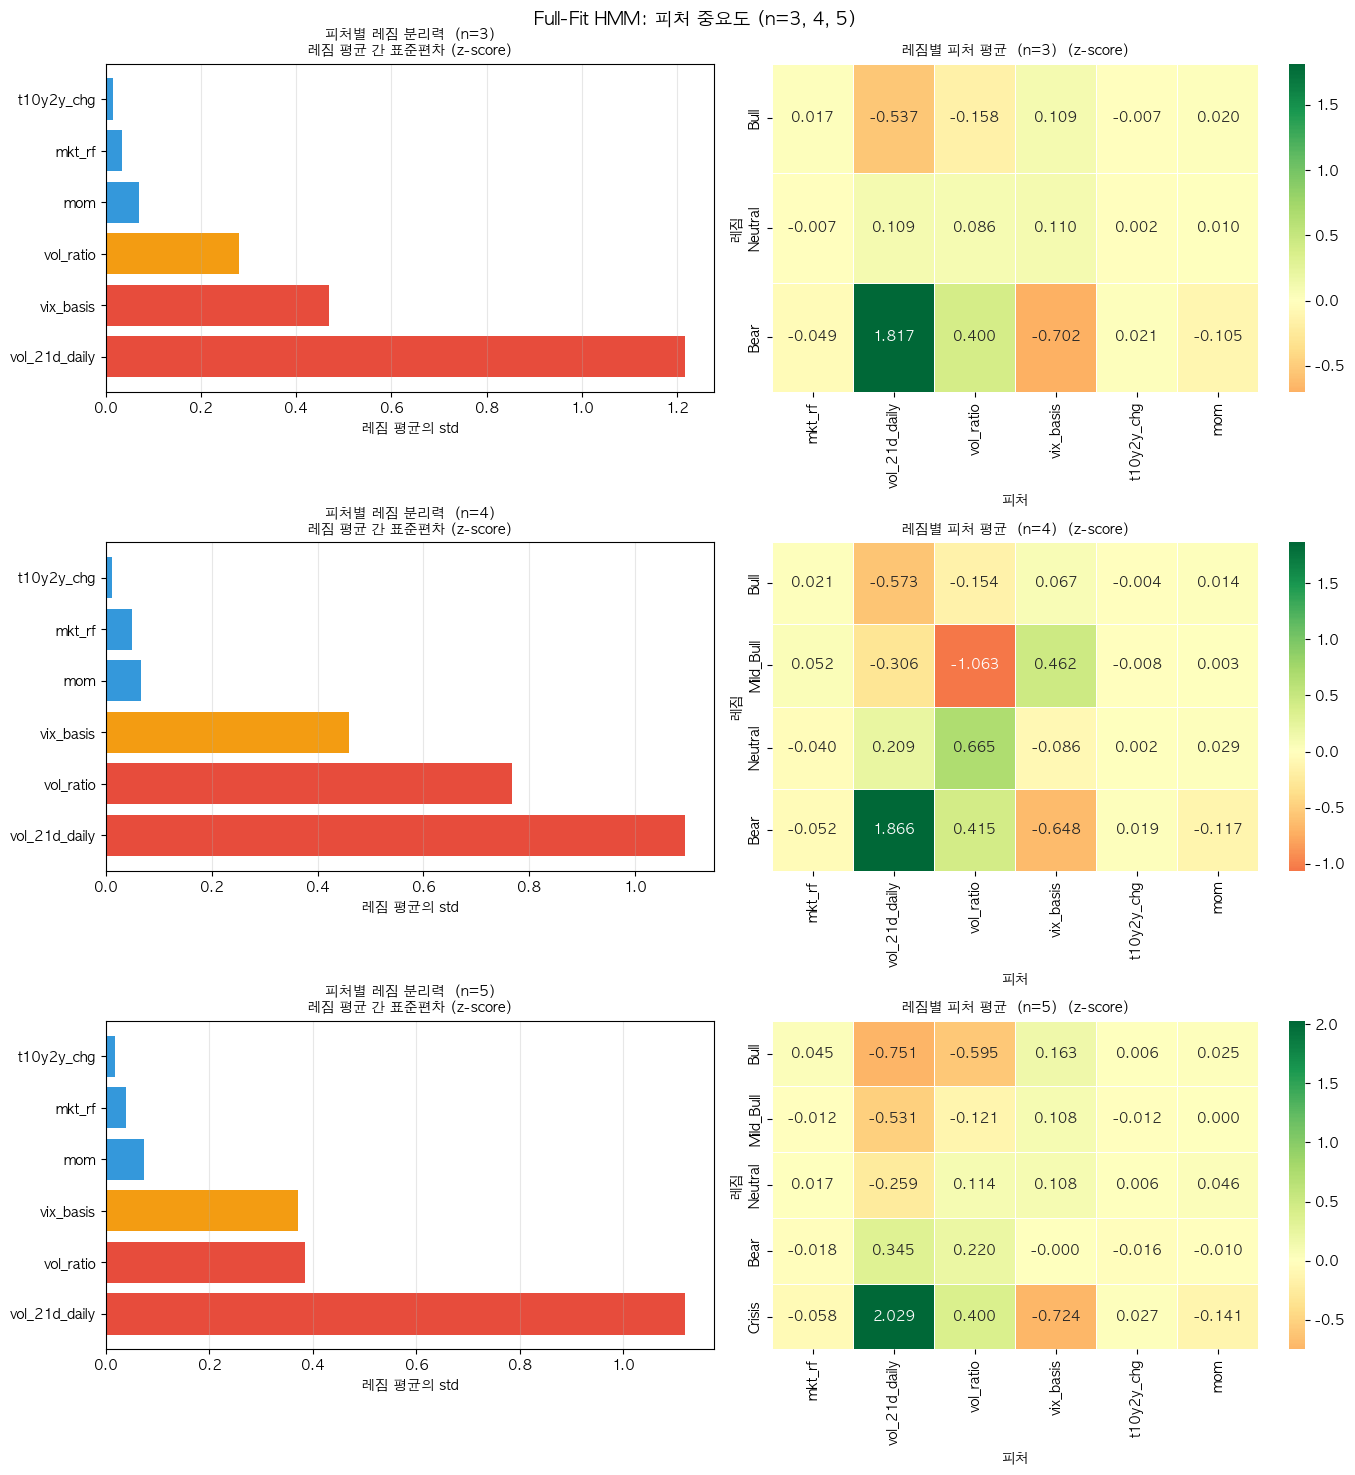

In [14]:
# ── HMM 평균 벡터 기반 피처 중요도 (n=3, 4, 5) ───────────────────────────
fig, all_axes = plt.subplots(3, 2, figsize=(14, 15))

for row_idx, n in enumerate([3, 4, 5]):
    res        = results[n]
    best_model = res["model"]
    lbls       = res["labels"]

    # state_vols 기준 오름차순 정렬
    sorted_states = sorted(res["state_vols"].keys(),
                           key=lambda s: res["state_vols"][s])

    # z-score 공간 평균 (왼쪽 바차트 + 오른쪽 히트맵 공용)
    means_z    = pd.DataFrame(best_model.means_[sorted_states],
                               columns=feat_df.columns, index=lbls)
    importance = means_z.std(axis=0).sort_values(ascending=False)

    axes       = all_axes[row_idx]
    colors_imp = ["#e74c3c" if v >= importance.quantile(0.75)
                  else "#f39c12" if v >= importance.quantile(0.5)
                  else "#3498db" for v in importance]

    # ── 왼쪽: 피처별 분리력 바차트 ──────────────────────────────────────────
    axes[0].barh(importance.index, importance.values, color=colors_imp)
    axes[0].set_title(f"피처별 레짐 분리력  (n={n})\n레짐 평균 간 표준편차 (z-score)",
                      fontweight="bold", fontsize=10)
    axes[0].set_xlabel("레짐 평균의 std")
    axes[0].grid(axis="x", alpha=0.3)

    # ── 오른쪽: 레짐별 피처 평균 히트맵 ────────────────────────────────────
    sns.heatmap(means_z, annot=True, fmt=".3f", cmap="RdYlGn",
                center=0, linewidths=0.5, ax=axes[1])
    axes[1].set_title(f"레짐별 피처 평균  (n={n})  (z-score)",
                      fontweight="bold", fontsize=10)
    axes[1].set_xlabel("피처")
    axes[1].set_ylabel("레짐")

    # ── 콘솔 출력 ───────────────────────────────────────────────────────────
    print(f"n={n}  레짐 분리력 순위:")
    for rank, (fname, val) in enumerate(importance.items(), 1):
        tier = "🔴 HIGH" if val >= importance.quantile(0.75) else \
               "🟡 MID " if val >= importance.quantile(0.5) else "🔵 LOW "
        print(f"  {rank}. {fname:<15}  std={val:.4f}  {tier}")
    print()

plt.suptitle("Full-Fit HMM: 피처 중요도 (n=3, 4, 5)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "V4_feature_importance.png", bbox_inches="tight")
plt.show()

---
**Full-Fit HMM 요약**

- 레짐 분리 주도 피처: **`vol_21d_daily`** 가 전 n에서 분리력 1위 (std≈1.1) 로 일관. `vol_ratio`·`vix_basis` 가 2~3위로 n 에 따라 순서 바뀜 (모두 HIGH/MID 등급)
- 타임라인: GFC(2008), 코로나(2020), 2022 Bear 구간에서 Bear/Crisis 레짐이 뚜렷하게 포착됨
- n이 커질수록 Bull이 `Mild_Bull`로 세분화되며, Bear·Crisis 구간은 n에 관계없이 일관

→ HMM이 시장 상태를 의미 있는 방식으로 구분하고 있으며, 변동성 중심의 레짐 구조가 데이터에 존재함을 확인

## 5. 레짐 통계 비교

In [15]:
print("=" * 72)
print("   레짐 수별 통계 비교")
print("=" * 72)
print(f"분석 기간: {feat_df.index[0].date()} ~ {feat_df.index[-1].date()}   총 거래일: {len(feat_df):,}일\n")

vix_aligned = feat.loc[feat_df.index, "vix"]

for n in [3, 4, 5]:
    r = results[n]
    s_arr = np.array(r["states"])
    lbls = r["labels"]
    print(f"  n={n}")
    for i, lbl in enumerate(lbls):
        mask = s_arr == i
        count = int(mask.sum())
        pct = count / len(s_arr) * 100
        mean_ret = feat_df["mkt_rf"].values[mask].mean()
        mean_vol = feat_df["vol_21d_daily"].values[mask].mean()
        mean_vix = vix_aligned.values[mask].mean()
        print(f"  [{lbl:<16}]  {pct:5.1f}%  ({count:4d}일)  "
              f"수익(일)={mean_ret*100:+.3f}%  "
              f"변동(일)={mean_vol*100:.3f}%  "
              f"VIX={mean_vix:.1f}")
    print()


   레짐 수별 통계 비교
분석 기간: 2004-04-01 ~ 2023-12-29   총 거래일: 4,971일

  n=3
  [Bull            ]   52.6%  (2616일)  수익(일)=+0.061%  변동(일)=0.646%  VIX=13.8
  [Neutral         ]   34.0%  (1690일)  수익(일)=+0.024%  변동(일)=1.095%  VIX=21.0
  [Bear            ]   13.4%  ( 665일)  수익(일)=-0.007%  변동(일)=2.286%  VIX=35.6

  n=4
  [Bull            ]   42.2%  (2097일)  수익(일)=+0.066%  변동(일)=0.620%  VIX=13.2
  [Mild_Bull       ]   16.4%  ( 817일)  수익(일)=+0.097%  변동(일)=0.805%  VIX=18.2
  [Neutral         ]   28.9%  (1435일)  수익(일)=-0.006%  변동(일)=1.163%  VIX=21.0
  [Bear            ]   12.5%  ( 622일)  수익(일)=-0.020%  변동(일)=2.304%  VIX=36.4

  n=5
  [Bull            ]   18.2%  ( 906일)  수익(일)=+0.096%  변동(일)=0.497%  VIX=11.8
  [Mild_Bull       ]   18.0%  ( 893일)  수익(일)=+0.021%  변동(일)=0.650%  VIX=13.9
  [Neutral         ]   29.1%  (1446일)  수익(일)=+0.063%  변동(일)=0.840%  VIX=16.9
  [Bear            ]   23.8%  (1182일)  수익(일)=+0.011%  변동(일)=1.259%  VIX=23.0
  [Crisis          ]   10.9%  ( 544일)  수익(일)=-0.024%  변동(일)=2.438%  VI

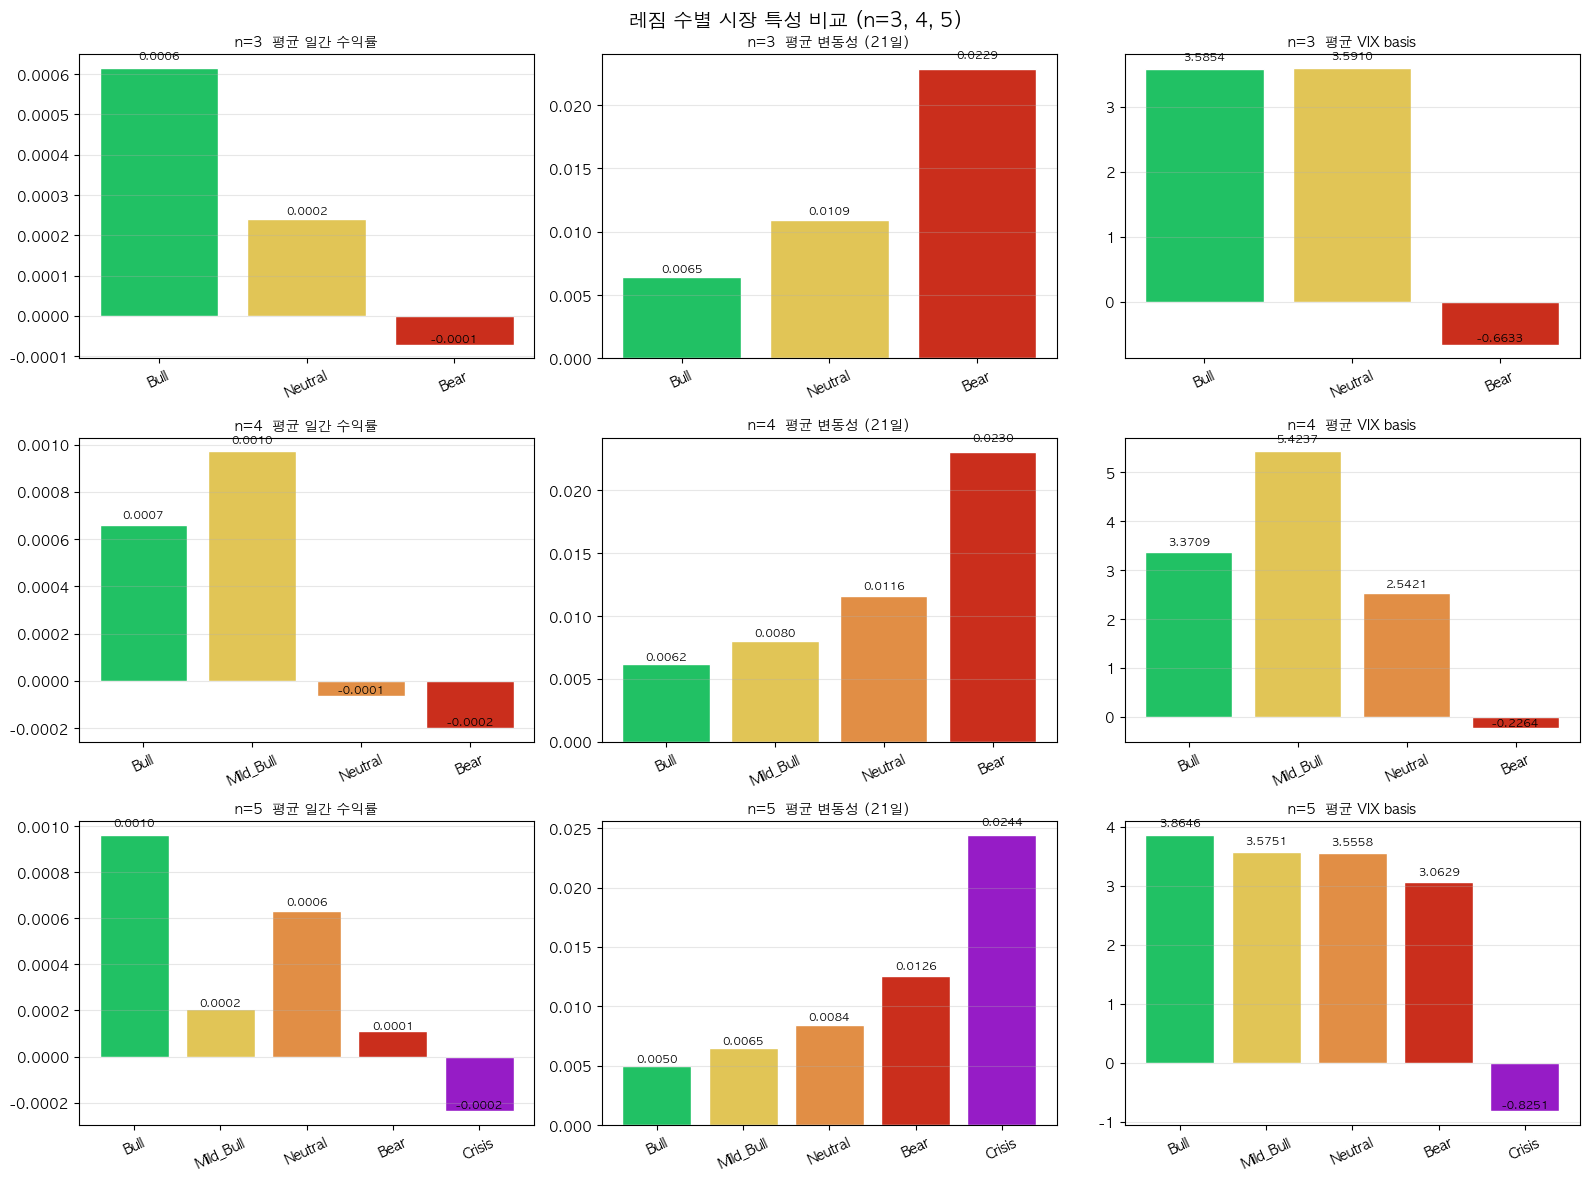

In [16]:
metrics = [("mkt_rf", "평균 일간 수익률"), ("vol_21d_daily", "평균 변동성 (21일)"), ("vix_basis", "평균 VIX basis")]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for row_idx, n in enumerate([3, 4, 5]):
    res    = results[n]
    s_arr  = np.array(res["states"])
    lbls   = res["labels"]
    colors = N_COLORS[n]

    # 레짐별 통계 계산
    rows = []
    for i, lbl in enumerate(lbls):
        mask = s_arr == i
        row  = {"label": lbl}
        for col, _ in metrics:
            row[col] = feat_df.loc[mask, col].mean() if col in feat_df.columns else np.nan
        rows.append(row)
    st = pd.DataFrame(rows)

    for col_idx, (col, title) in enumerate(metrics):
        ax = axes[row_idx][col_idx]
        bars = ax.bar(st["label"], st[col], color=colors, edgecolor="white")
        ax.set_title(f"n={n}  {title}", fontweight="bold", fontsize=10)
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.3)
        for bar, val in zip(bars, st[col]):
            if pd.notna(val):
                ypos = bar.get_height() + abs(bar.get_height()) * 0.03
                ax.text(bar.get_x() + bar.get_width()/2, ypos,
                        f"{val:.4f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("레짐 수별 시장 특성 비교 (n=3, 4, 5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_regime_stats_comparison.png", bbox_inches="tight")
plt.show()


---
**레짐 통계 요약** (K_CUT=2023-12-31, n=3)

| 레짐(n=3) | 비중 | 일수 | 수익(일) | 변동성(일) | VIX |
|-----------|-----:|-----:|---------:|----------:|----:|
| Bull      | 52.6% | 2,616일 | +0.061% | 0.646% | 13.8 |
| Neutral   | 34.0% | 1,690일 | +0.024% | 1.095% | 21.0 |
| Bear      | 13.4% |   665일 | −0.007% | 2.286% | 35.6 |

> 수익·변동성 모두 **일별 단위** (mkt_rf 일별 수익률 / vol_21d_daily 일별 std). VIX 는 연환산 % (참고).
> 본 노트북 내부에서는 일별 단위로 통일. 연환산은 `vix_basis` 계산에서만 사용 (VIX 와 단위 맞춤).

- Bear 레짐의 변동성은 Bull 대비 **3.5배** (2.286/0.646), VIX는 **2.6배** (35.6/13.8) 높음
- 수익률·변동성·VIX 모두 Bull → Neutral → Bear 순서로 단조 증가/감소

→ **레짐 = 서로 다른 시장 체질**임을 보여줌


## 6. 피처 분포 비교

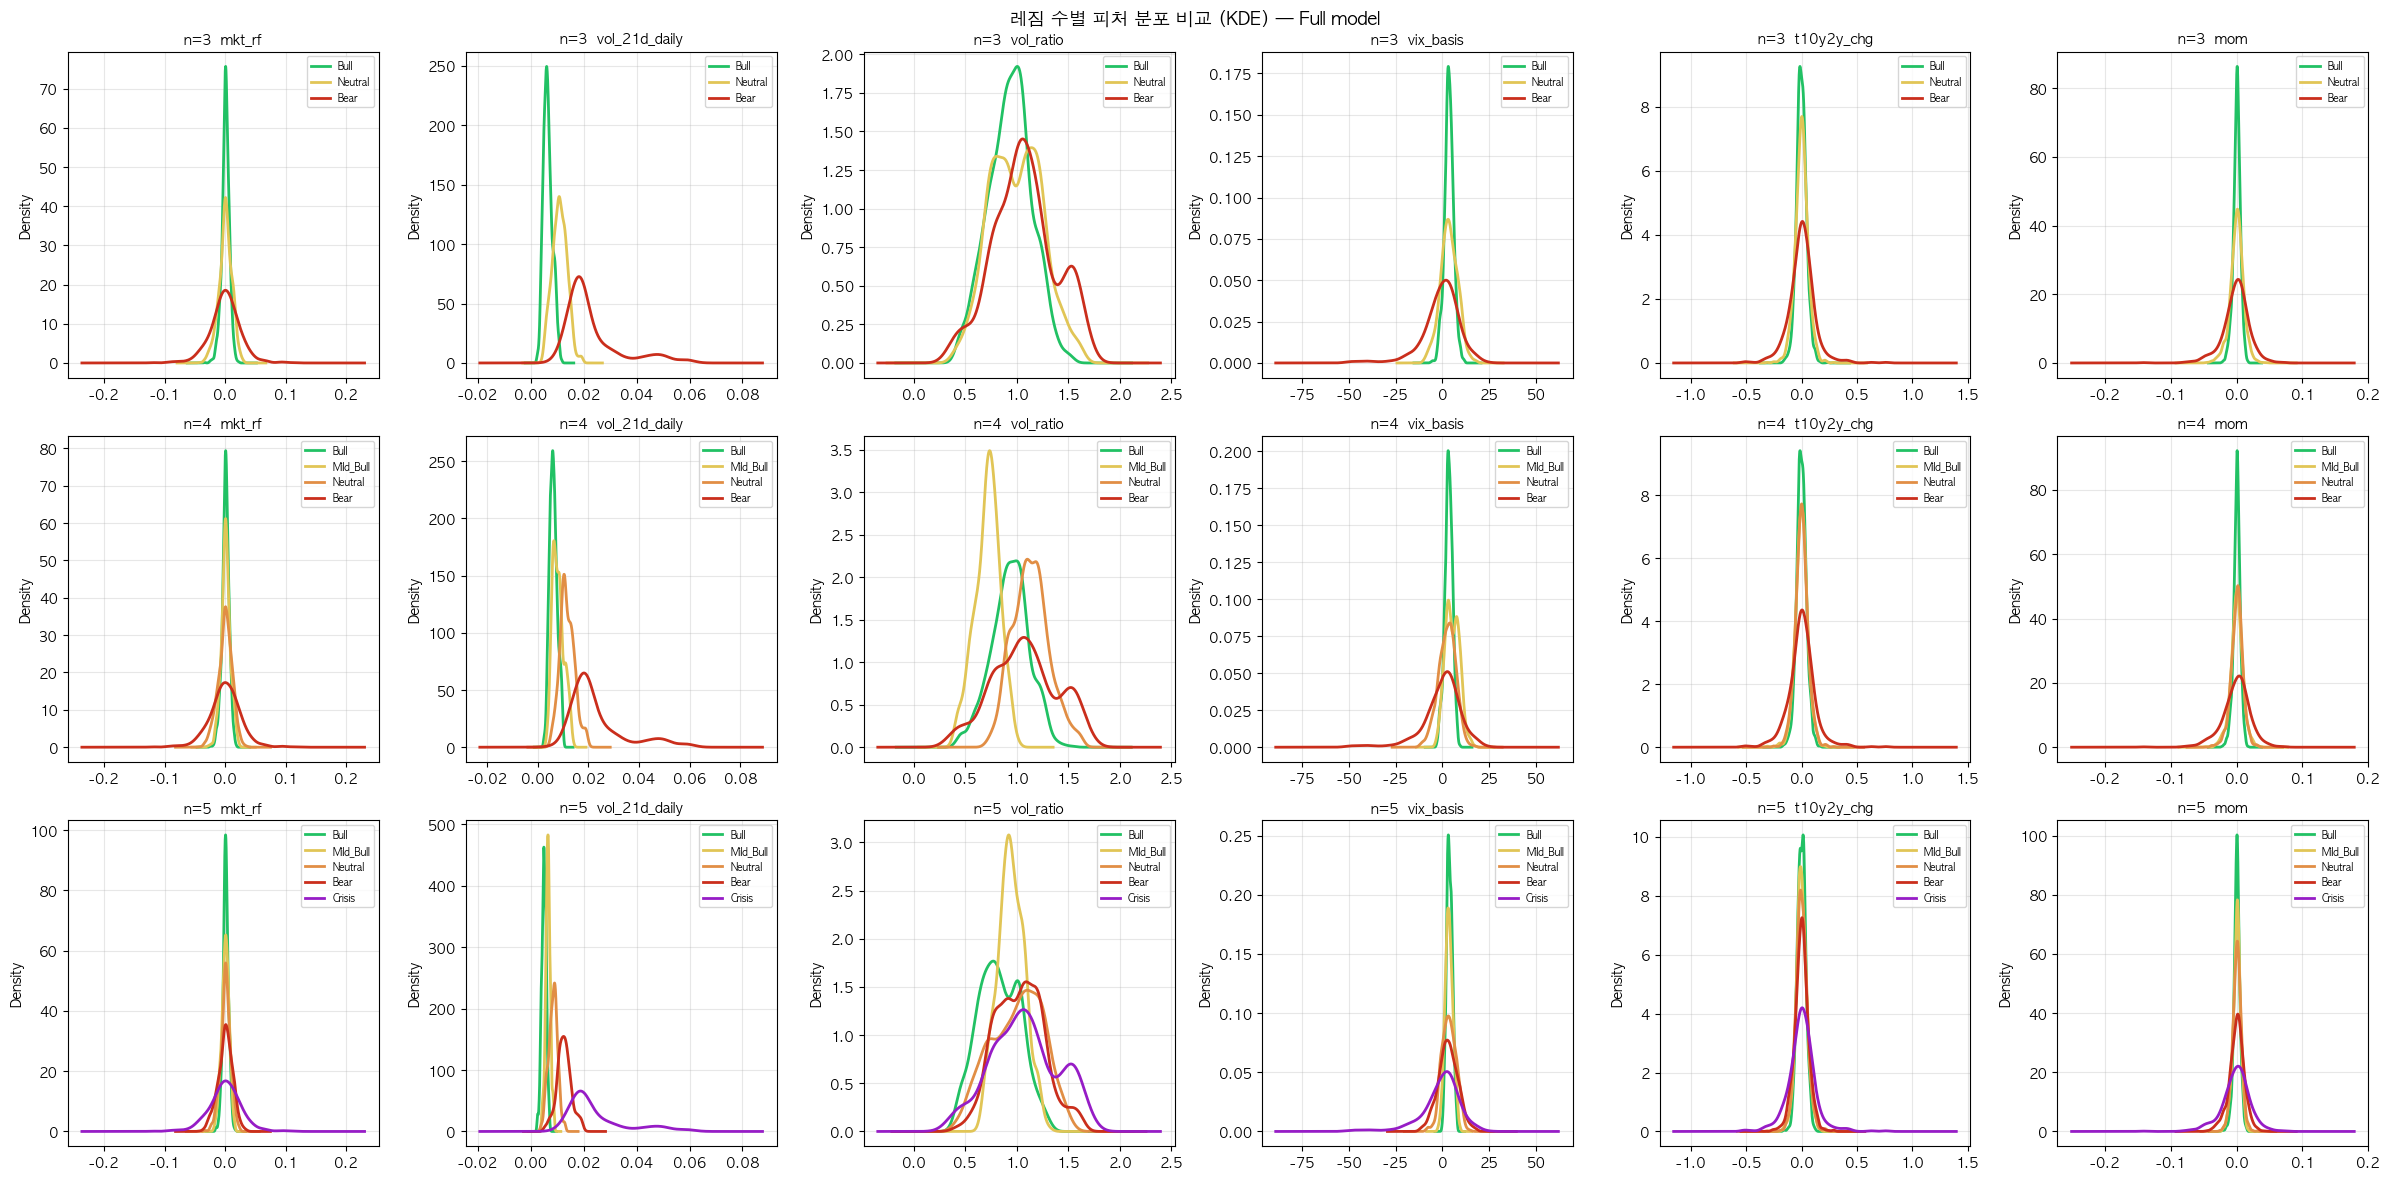

In [17]:
plot_feats = feat_df.columns.tolist()

fig, axes = plt.subplots(3, len(plot_feats), figsize=(4*len(plot_feats), 12))

for row_idx, n in enumerate([3, 4, 5]):
    res   = results[n]
    s_arr = np.array(res["states"])
    lbls  = res["labels"]
    colors = N_COLORS[n]

    for col_idx, fname in enumerate(plot_feats):
        ax = axes[row_idx][col_idx]
        for i, (lbl, color) in enumerate(zip(lbls, colors)):
            vals = feat_df[fname].values[s_arr == i]
            vals = vals[~np.isnan(vals)]
            if len(vals) < 2:
                continue
            pd.Series(vals).plot.kde(ax=ax, label=lbl, color=color, lw=2)
        ax.set_title(f"n={n}  {fname}", fontsize=10)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("레짐 수별 피처 분포 비교 (KDE) — Full model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "05_kde_comparison.png", bbox_inches="tight")
plt.show()


---
**피처 분포 요약**

- `mkt_rf`·`vol_21d_daily`·`vix_basis` 모두 레짐별 KDE가 명확히 분리 → 레짐 구분이 통계적으로 유의미
- Bear 레짐의 `vix_basis`는 음수에 집중: 패닉 국면에서 실현 변동성이 기대 변동성을 초과하는 현상
- 분포가 겹치는 영역이 적을수록 HMM이 학습한 레짐 경계의 신뢰도가 높음

## 7. 전이 행렬 비교

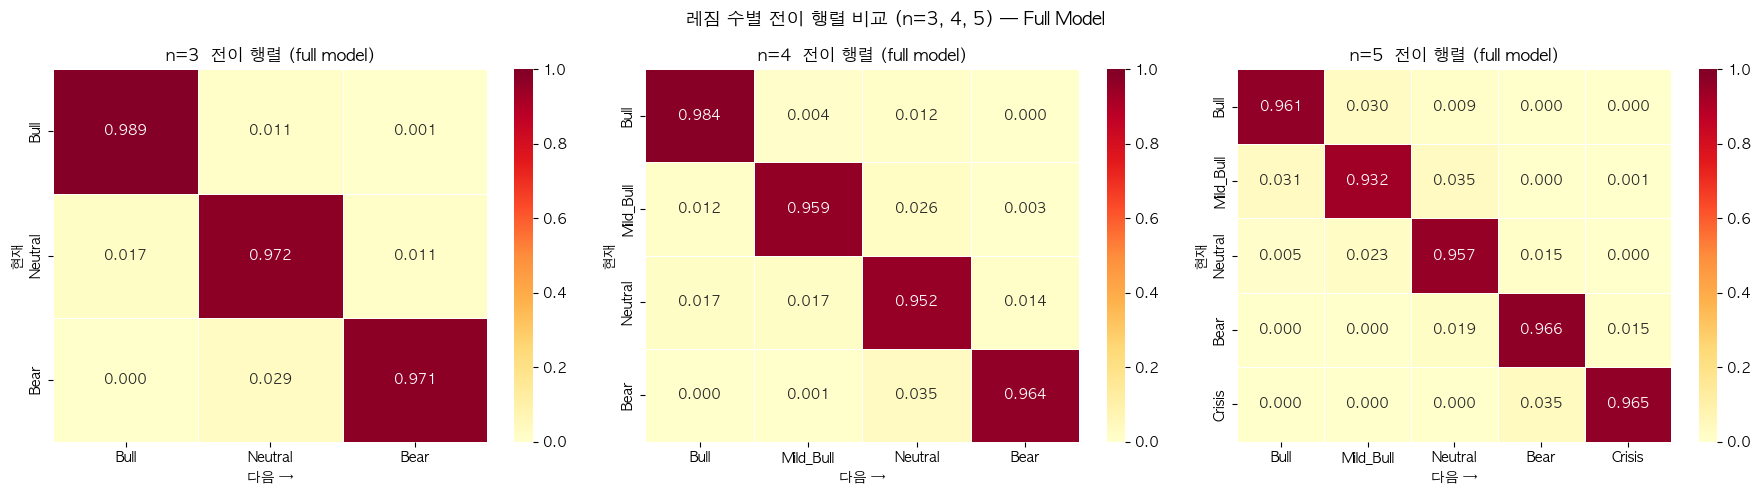

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, n in zip(axes, [3, 4, 5]):
    res      = results[n]
    trans_df = res["trans_matrix"]
    sns.heatmap(trans_df, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"n={n}  전이 행렬 (full model)", fontweight="bold", fontsize=12)
    ax.set_xlabel("다음 →"); ax.set_ylabel("현재")

plt.suptitle("레짐 수별 전이 행렬 비교 (n=3, 4, 5) — Full Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_transition_comparison.png", bbox_inches="tight")
plt.show()


---
**전이 행렬 요약**

- 대각선(자기전이) 확률이 0.97 이상 → 레짐은 하루 단위 노이즈가 아닌 **수 주~수 달 지속되는 안정적 상태**
- Bull ↔ Bear 직접 전이 확률은 사실상 0 → 레짐은 인접 상태를 거쳐 점진적으로 전환
- 높은 레짐 지속성 = 레짐 신호를 실제 포트폴리오 리밸런싱에 활용할 수 있는 조건

→ 레짐이 충분히 지속되기 때문에, 전환점 이후 새 레짐 기준으로 포트폴리오를 재설정하는 전략이 실행 가능

## 8. 구조적 전환점 분석
Viterbi 경로에서 **이전 레짐 ≥ N거래일 + 새 레짐 ≥ N거래일** 조건을 모두 만족하는 전환만 구조적 전환점으로 정의한다.

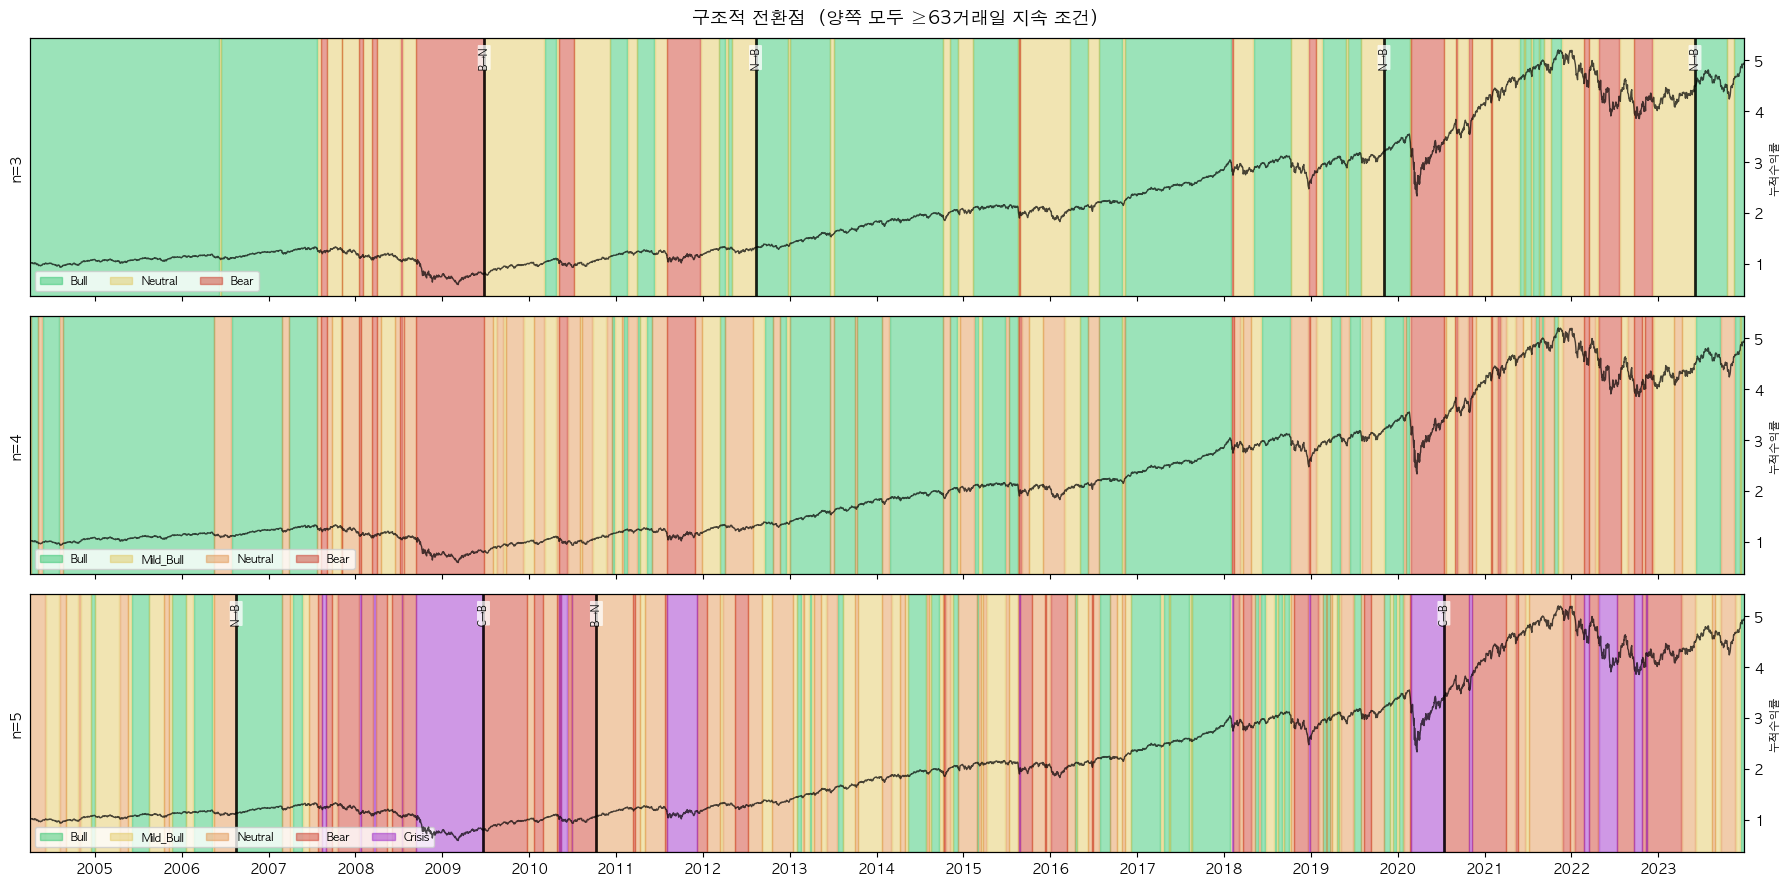

구조적 전환점 요약  (min_duration=63거래일)

n=3  (4개 전환점)
  날짜            전환                          이전      이후
  ----------------------------------------------------
  2009-06-26    Bear       → Neutral       198일    174일
  2012-08-10    Neutral    → Bull           69일     93일
  2019-11-05    Neutral    → Bull           67일     74일
  2023-06-05    Neutral    → Bull          120일     94일

n=4  (0개 전환점)
  날짜            전환                          이전      이후
  ----------------------------------------------------

n=5  (4개 전환점)
  날짜            전환                          이전      이후
  ----------------------------------------------------
  2006-08-18    Neutral    → Bull           64일    130일
  2009-06-23    Crisis     → Bear          195일    127일
  2010-10-11    Bear       → Neutral        69일    107일
  2020-07-14    Crisis     → Bear           95일     74일



In [19]:
MIN_DURATION = 63  # 최소 ~3개월(63거래일) 지속 시 구조적 전환으로 인정

def find_structural_breaks(states, dates, labels, min_duration=MIN_DURATION):
    states = np.array(states)
    # 연속 런(run) 추출
    runs = []
    i = 0
    while i < len(states):
        j = i + 1
        while j < len(states) and states[j] == states[i]:
            j += 1
        runs.append((i, j - 1, states[i]))
        i = j

    breaks = []
    for k in range(1, len(runs)):
        prev, curr = runs[k - 1], runs[k]
        prev_dur = prev[1] - prev[0] + 1
        curr_dur = curr[1] - curr[0] + 1
        if prev_dur >= min_duration and curr_dur >= min_duration:
            breaks.append({
                "date":     dates[curr[0]],
                "from":     labels[prev[2]],
                "to":       labels[curr[2]],
                "prev_dur": prev_dur,
                "curr_dur": curr_dur,
            })
    return breaks

# ── 시각화 ────────────────────────────────────────────────────────────────────
cum_ret = (1 + feat_df["mkt_rf"]).cumprod()
fig, axes = plt.subplots(3, 1, figsize=(18, 9), sharex=True)

for ax, n in zip(axes, [3, 4, 5]):
    res    = results[n]
    s_arr  = np.array(res["states"])
    lbls   = res["labels"]
    dates  = feat_df.index
    breaks = find_structural_breaks(s_arr, dates, lbls)

    for regime, color in enumerate(N_COLORS[n]):
        ax.fill_between(dates, 0, 1, where=(s_arr == regime),
                        color=color, alpha=0.45, label=lbls[regime])

    for bp in breaks:
        ax.axvline(bp["date"], color="black", lw=2, alpha=0.85)
        ax.text(bp["date"], 0.97,
                f"{bp['from'][0]}→{bp['to'][0]}",
                fontsize=7, ha="center", va="top", rotation=90,
                bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.75, ec="none"))

    ax2 = ax.twinx()
    ax2.plot(dates, cum_ret, color="black", lw=1.0, alpha=0.7)
    ax2.set_ylabel("누적수익률", fontsize=8)

    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.set_ylabel(f"n={n}", fontsize=10)
    ax.legend(loc="lower left", ncol=n, fontsize=8)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlim(feat_df.index[0], feat_df.index[-1])
plt.suptitle(f"구조적 전환점  (양쪽 모두 ≥{MIN_DURATION}거래일 지속 조건)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "P3_structural_breaks.png", bbox_inches="tight")
plt.show()

# ── 전환점 테이블 ─────────────────────────────────────────────────────────────
print(f"구조적 전환점 요약  (min_duration={MIN_DURATION}거래일)\n")
for n in [3, 4, 5]:
    res    = results[n]
    s_arr  = np.array(res["states"])
    lbls   = res["labels"]
    breaks = find_structural_breaks(s_arr, feat_df.index, lbls)
    print(f"n={n}  ({len(breaks)}개 전환점)")
    print(f"  {'날짜':<12}  {'전환':<22}  {'이전':>6}  {'이후':>6}")
    print("  " + "-" * 52)
    for bp in breaks:
        print(f"  {str(bp['date'].date()):<12}  "
              f"{bp['from']:<10} → {bp['to']:<10}  "
              f"{bp['prev_dur']:>5}일  {bp['curr_dur']:>5}일")
    print()


---
**구조적 전환점 요약** (K_CUT=2023-12-31, n=3)

- 63거래일(~3개월) 양방향 지속 조건을 적용해 단기 노이즈 제거 후 주요 전환점만 추출
- 추출된 전환점이 **GFC 회복 (2009)**, **post-GFC 회복기 종료 (2012)**, **COVID 직전 (2019)**, **AI 랠리 시작 (2023)** 등 실제 시장 사건과 시기적으로 일치
- 각 서브 기간은 지배적인 레짐이 다른 별개의 시장 환경으로 해석 가능

| HMM 전환점 (K_CUT=2023) | 시장 사건 |
|---|---|
| **2009-06-26** (Bear→Neutral) | GFC 회복 시작 |
| **2012-08-10** (Neutral→Bull) | post-GFC 회복기 종료 → 본격 Bull |
| **2019-11-05** (Neutral→Bull) | COVID 직전 강세 |
| **2023-06-05** (Neutral→Bull) | AI 랠리 시작 |

→ HMM 구조전환점을 분기/연말 boundary 로 round 하고 경제적 직관(COVID 시작)에 맞춰 **`master_table.REGIMES`** 로 정의:

| 레짐 | 기간 (master_table.REGIMES) | HMM 원본 전환점 | round 근거 |
|---|---|---|---|
| **R1 회복**  | 2010-01-01 ~ 2012-06-30 (30m) | 2009-06-26 (B→N), 2012-08-10 (N→B) | GFC 회복 후 안정화 6개월 buffer, 분기말 round |
| **R2 확장**  | 2012-07-01 ~ 2019-12-31 (90m) | 2019-11-05 (Neutral→Bull) | 연말 round, COVID 시작과 align |
| **R3 변동**  | 2020-01-01 ~ 2024-12-31 (60m) | — | COVID + 2022 Bear + AI 랠리 통합 (경제적 직관) |

> HMM n=3 의 마지막 전환점 **2023-06-05 (AI 랠리 시작)** 는 master_table.REGIMES R3 안에 묻혀 있음. 4-레짐 분석(`06_Regime_Analysis.ipynb`) 의 R3/R4 boundary (2023-07-01) 가 이를 별도 분리.

> `05b_Analyze.ipynb` 에서 **K_CUT=2023-12-31** 적용 시 R3 = 2020-01 ~ 2023-12 (48m) 로 truncate (2024~2025 hold-out 보존).


## 9. Posterior 불확실성 분석
모델이 레짐을 얼마나 확신하는가?

In [20]:
# ── Posterior 불확실성 분석 ─────────────────────────────────────────────────
print("=" * 72)
print("   모델 확신도 요약")
print("=" * 72)

for n in [3, 4, 5]:
    res      = results[n]
    proba    = res["model"].predict_proba(X_scaled)
    max_prob = proba.max(axis=1)
    pct_high = (max_prob >= 0.9).mean() * 100
    pct_mid  = ((max_prob >= 0.7) & (max_prob < 0.9)).mean() * 100
    pct_low  = (max_prob < 0.7).mean() * 100
    print(f"\nn = {n}")
    print(f"  평균 max_posterior : {max_prob.mean():.3f}")
    print(f"  ≥ 90%  고확신      : {pct_high:.1f}%  ({(max_prob >= 0.9).sum():,}일)")
    print(f"  70~90% 중간 확신   : {pct_mid:.1f}%  ({((max_prob >= 0.7) & (max_prob < 0.9)).sum():,}일)")
    print(f"  < 70%  불확실      : {pct_low:.1f}%  ({(max_prob < 0.7).sum():,}일)")


   모델 확신도 요약

n = 3
  평균 max_posterior : 0.984
  ≥ 90%  고확신      : 95.0%  (4,723일)
  70~90% 중간 확신   : 3.2%  (160일)
  < 70%  불확실      : 1.8%  (88일)

n = 4
  평균 max_posterior : 0.979
  ≥ 90%  고확신      : 93.1%  (4,626일)
  70~90% 중간 확신   : 4.7%  (234일)
  < 70%  불확실      : 2.2%  (111일)

n = 5
  평균 max_posterior : 0.971
  ≥ 90%  고확신      : 91.0%  (4,525일)
  70~90% 중간 확신   : 5.5%  (271일)
  < 70%  불확실      : 3.5%  (175일)


---
**Posterior 불확실성 요약** (K_CUT=2023-12-31)

| n | 평균 max_posterior | ≥90% 고확신 | 70~90% | <70% 불확실 |
|---|-------------------:|-----------:|-------:|-----------:|
| 3 | 0.984 | 95.0% (4,723일) | 3.2% | 1.8% |
| 4 | 0.979 | 93.1% (4,626일) | 4.7% | 2.2% |
| 5 | 0.971 | 91.0% (4,525일) | 5.5% | 3.5% |

- 전 n에서 90% 이상 고확신 구간이 91%+ → 모델이 대부분의 날에 레짐을 명확히 분류
- 불확실 구간(<70%)은 최대 3.5%로 극소수 → 레짐 경계 부근 모호한 날이 거의 없음

→ 레짐 레이블의 신뢰성이 충분히 확보됨. 이후 레짐 기반 포트폴리오 정의 및 백테스트에 활용 가능


## 10. CSV 저장

In [21]:
# n=3,4,5 각각 CSV 저장
for n in [3, 4, 5]:
    r     = results[n]
    s_arr = np.array(r["states"])
    lbls  = r["labels"]
    label_map = {i: lbl for i, lbl in enumerate(lbls)}

    # posterior 확률 (변동성 순 정렬)
    proba       = r["model"].predict_proba(X_scaled)
    vol_data    = feat_df["vol_21d_daily"].values
    state_vols  = {s: vol_data[s_arr == s].mean() if (s_arr == s).any() else float("inf")
                   for s in range(n)}
    sorted_st   = sorted(state_vols.keys(), key=lambda s: state_vols[s])
    proba_sorted = proba[:, sorted_st]

    out = feat_df[["mkt_rf", "vol_21d_daily"]].copy()
    out["state"]  = s_arr
    out["regime"] = [label_map[s] for s in s_arr]
    for i, lbl in enumerate(lbls):
        out[f"prob_{lbl}"] = proba_sorted[:, i]
    out.to_csv(OUT_DIR / f"hmm_n{n}_results.csv")

print("✅ CSV 저장 완료")
for n in [3, 4, 5]:
    print(f"   - hmm_n{n}_results.csv")


✅ CSV 저장 완료
   - hmm_n3_results.csv
   - hmm_n4_results.csv
   - hmm_n5_results.csv
